<a href="https://colab.research.google.com/github/hassan1662n/Deep-learning-projects/blob/main/10_food_classes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip

--2026-09-14 12:50:24--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.199.207, 74.125.20.207, 108.177.98.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.199.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 519183241 (495M) [application/zip]
Saving to: ‘10_food_classes_all_data.zip’

10_food_classes_all 100%[===================>] 495.13M   164MB/s    in 3.0s    

2026-09-14 12:50:27 (164 MB/s) - ‘10_food_classes_all_data.zip’ saved [519183241/519183241]



In [ ]:
import zipfile

# unzip
zip_ref = zipfile.ZipFile('10_food_classes_all_data.zip')
zip_ref.extractall()
zip_ref.close()

In [ ]:
!ls

10_food_classes_all_data  10_food_classes_all_data.zip	__MACOSX  sample_data


In [ ]:
!ls 10_food_classes_all_data

test  train


In [ ]:
!ls 10_food_classes_all_data/train

chicken_curry  fried_rice      hamburger  pizza  steak
chicken_wings  grilled_salmon  ice_cream  ramen  sushi


In [ ]:
import os

for dirpath, dirnames, filenames in os.walk('10_food_classes_all_data'):
  print(f"there are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

there are 2 directories and 0 images in '10_food_classes_all_data'.
there are 10 directories and 0 images in '10_food_classes_all_data/train'.
there are 0 directories and 750 images in '10_food_classes_all_data/train/chicken_curry'.
there are 0 directories and 750 images in '10_food_classes_all_data/train/chicken_wings'.
there are 0 directories and 750 images in '10_food_classes_all_data/train/sushi'.
there are 0 directories and 750 images in '10_food_classes_all_data/train/grilled_salmon'.
there are 0 directories and 750 images in '10_food_classes_all_data/train/pizza'.
there are 0 directories and 750 images in '10_food_classes_all_data/train/ice_cream'.
there are 0 directories and 750 images in '10_food_classes_all_data/train/hamburger'.
there are 0 directories and 750 images in '10_food_classes_all_data/train/fried_rice'.
there are 0 directories and 750 images in '10_food_classes_all_data/train/ramen'.
there are 0 directories and 750 images in '10_food_classes_all_data/train/steak'.

In [ ]:
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [ ]:
def view_image(target_dir, target_class):
  target_folder = target_dir + target_class

  random_image = random.sample(os.listdir(target_folder), 1)

  img = mpimg.imread(target_folder + "/" + random_image[0])
  plt.imshow(img)
  plt.title(target_class)
  plt.axis("off")
  print(f"image shape: {img.shape}")

  return img

image shape: (384, 512, 3)


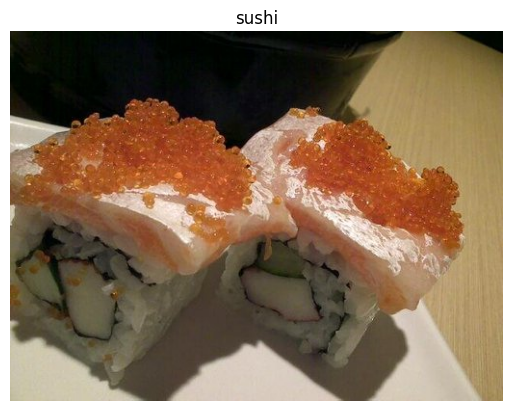

In [ ]:
img = view_image(target_dir='10_food_classes_all_data/train/', target_class='sushi')

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMAGE_SHAPE = (224, 224)
BATCH_SIZE = 32

test_dir = "/content/10_food_classes_all_data/test"
train_dir = "/content/10_food_classes_all_data/train"

train_datagen = ImageDataGenerator(rescale=1/255.)
test_datagen = ImageDataGenerator(rescale=1/255.)

print("Training images:")
train_data = train_datagen.flow_from_directory(train_dir,
                                               target_size=IMAGE_SHAPE,
                                               batch_size=BATCH_SIZE,
                                               class_mode="categorical")

print("Testing images:")
test_data = train_datagen.flow_from_directory(test_dir,
                                              target_size=IMAGE_SHAPE,
                                              batch_size=BATCH_SIZE,
                                              class_mode="categorical")


Training images:
Found 7500 images belonging to 10 classes.
Testing images:
Found 2500 images belonging to 10 classes.


In [ ]:
50500/16

3156.25

In [ ]:
import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras import regularizers
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten
from tensorflow.keras.layers import Convolution2D, MaxPooling2D, ZeroPadding2D, GlobalAveragePooling2D, AveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.regularizers import l2
from tensorflow import keras
import numpy as np



K.clear_session()

n_classes = 10 # Changed from 3 to 10 to match the dataset
img_width, img_height = 299, 299
train_data_dir = "/content/10_food_classes_all_data/train"
validation_data_dir = "/content/10_food_classes_all_data/test"
batch_size = 16

train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1. / 255)

train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical')

validation_generator = test_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical')


inception = InceptionV3(weights='imagenet', include_top=False)
x = inception.output
x = GlobalAveragePooling2D()(x)
x = Dense(128,activation='relu')(x)
x = Dropout(0.2)(x)

predictions = Dense(n_classes,kernel_regularizer=regularizers.l2(0.005), activation='softmax')(x) # Changed from 3 to n_classes

model = Model(inputs=inception.input, outputs=predictions)
model.compile(optimizer=SGD(learning_rate=0.0001, momentum=0.9), loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(train_generator,
                    validation_data=validation_generator,
                    epochs=10,
                    verbose=1,
)


Found 7500 images belonging to 10 classes.
Found 2500 images belonging to 10 classes.
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 309s 551ms/step - accuracy: 0.3503 - loss: 2.0755 - val_accuracy: 0.7000 - val_loss: 1.4540
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 212s 452ms/step - accuracy: 0.6591 - loss: 1.3198 - val_accuracy: 0.8220 - val_loss: 0.8101
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 224s 478ms/step - accuracy: 0.7399 - loss: 0.9678 - val_accuracy: 0.8684 - val_loss: 0.5817
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 216s 461ms/step - accuracy: 0.7803 - loss: 0.8150 - val_accuracy: 0.8824 - val_loss: 0.4949
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 260s 457ms/step - accuracy: 0.8077 - loss: 0.7237 - val_accuracy: 0.9008 - val_loss: 0.4356
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 214s 456ms/step - accuracy: 0.8279 - loss: 0.6580 - val_accuracy: 0.9084 - val_loss: 0.4022
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 216s 461ms/step - accuracy: 0.8443 - loss: 0.6052 - val_accuracy: 0.9148 - val_los

Text(0.5, 0, 'Epoch')

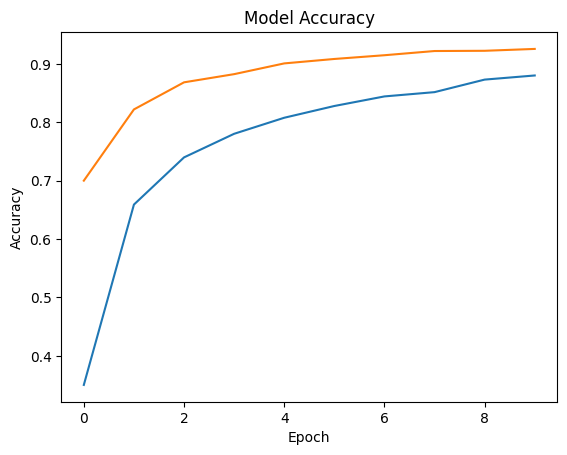

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

Text(0.5, 0, 'Epoch')

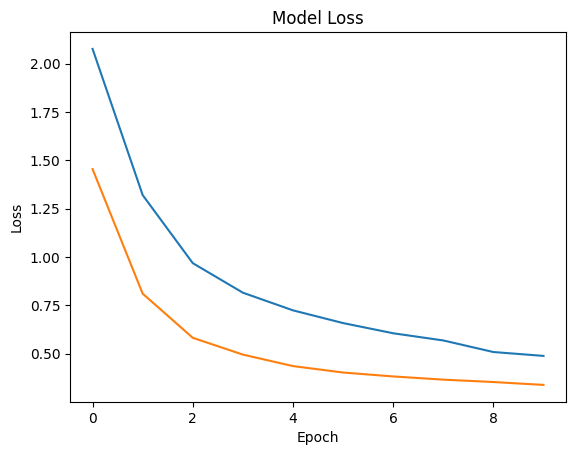

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')